In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

In [9]:
purchase = pd.read_csv("purchase.csv")
customer = pd.read_csv("customer.csv")

In [10]:
purchase.head()

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,26-05-2020,9,8.91,29-05-2020
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,29-12-2022,9,13.95,29-12-2022
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,06-03-2021,3,36.42,06-03-2021
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,11-03-2020,7,9.35,13-03-2020
4,ODSHP00005,CS00005,Rugs,Add warmth and texture to your floors with the...,1785.38,0.13,0.00,12-03-2022,7,8.55,15-03-2022


In [11]:
customer.head()

,customer_id,first_name,last_name,gender,age,country,income
0,CS00001,Isadora,Porto,Female,19,Brazil,117196
1,CS00002,Hugo,Carreño,Male,33,Chile,49256
2,CS00003,René,Olivera,Male,65,Mexico,33434
3,CS00004,Luiz Henrique,Pinto,Male,55,Brazil,75302
4,CS00005,Leonardo,Monteiro,Male,19,Brazil,32280


In [12]:
purchase.columns

Index(['order_id', 'customer_id', 'product_name', 'description', 'price',
       'discount', 'tax', 'order_date', 'quantity', 'shipping_cost',
       'shipping_date'],
      dtype='object')

In [13]:
customer.columns

Index(['customer_id', 'first_name', 'last_name', 'gender', 'age', 'country',
       'income'],
      dtype='object')

In [15]:
## Merge the datasets
data = pd.merge(purchase, customer, on='customer_id')

In [16]:
data.head()

,order_id,customer_id,product_name,description,price,discount,tax,order_date,quantity,shipping_cost,shipping_date,first_name,last_name,gender,age,country,income
0,ODSHP00001,CS00001,Furniture,Transform your space with this stylish and fun...,645.52,0.37,0.02,26-05-2020,9,8.91,29-05-2020,Isadora,Porto,Female,19,Brazil,117196
1,ODSHP00002,CS00002,Dress,Look and feel your best with this elegant dress.,28.90,0.05,0.02,29-12-2022,9,13.95,29-12-2022,Hugo,Carreño,Male,33,Chile,49256
2,ODSHP00003,CS00003,Furniture,Transform your space with this stylish and fun...,3536.49,0.21,0.04,06-03-2021,3,36.42,06-03-2021,René,Olivera,Male,65,Mexico,33434
3,ODSHP00004,CS00004,Shoes,Step out in style with these fashionable shoes.,97.80,0.11,0.08,11-03-2020,7,9.35,13-03-2020,Luiz Henrique,Pinto,Male,55,Brazil,75302
4,ODSHP00005,CS00005,Rugs,Add warmth and texture to your floors with the...,1785.38,0.13,0.00,12-03-2022,7,8.55,15-03-2022,Leonardo,Monteiro,Male,19,Brazil,32280


In [17]:
## Revenue Analysis (Task 1)
data['Revenue'] = ((data['price'] - data['discount']) * data['quantity']) + data['tax']

data[['product_name', 'Revenue']].head()

,product_name,Revenue
0,Furniture,5806.37
1,Dress,259.67
2,Furniture,10608.88
3,Shoes,683.91
4,Rugs,12496.75


In [18]:
## Top 5 Products by Revenue
top5 = data.groupby('product_name')['Revenue'].sum().sort_values(ascending=False).head(5)

print(top5)

product_name
Curtains              24683780.74
Wall Art              24403787.04
Lighting              23894633.67
Furniture             23695609.84
Kitchen Appliances    23636096.99
Name: Revenue, dtype: float64


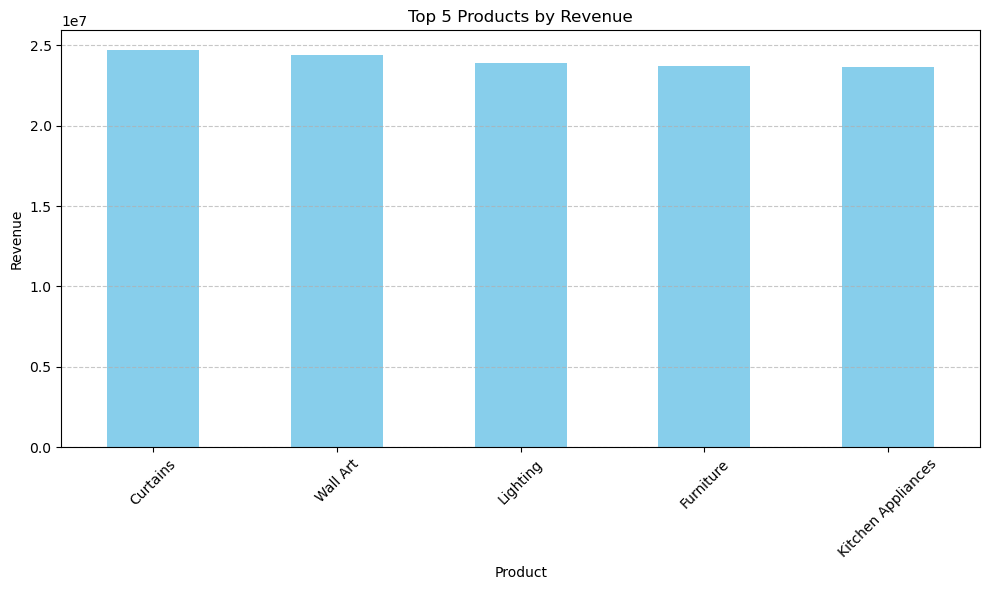

In [22]:
## Bar Chart
plt.figure(figsize=(10,6))

top5.plot(kind='bar', color='skyblue')

plt.title("Top 5 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [23]:
## Age Distribution
def age_group(age):
    if age <= 18:
        return "0-18"
    elif age <= 30:
        return "19-30"
    elif age <= 45:
        return "31-45"
    elif age <= 60:
        return "46-60"
    else:
        return "60+"

customer['Age_Group'] = customer['age'].apply(age_group)

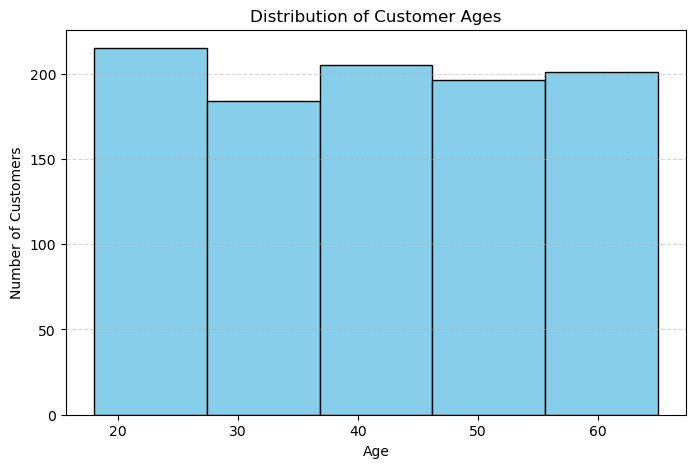

In [24]:
plt.figure(figsize=(8,5))

plt.hist(customer['age'], bins=5, color='skyblue', edgecolor='black')

plt.title("Distribution of Customer Ages")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [27]:
## Customers by Country
country_count = customer['country'].value_counts().reset_index()
country_count.columns = ['Country', 'Customer Count']

print(country_count)

    Country  Customer Count
0  Colombia             280
1     Chile             255
2    Brazil             234
3    Mexico             232


<Figure size 1000x600 with 0 Axes>

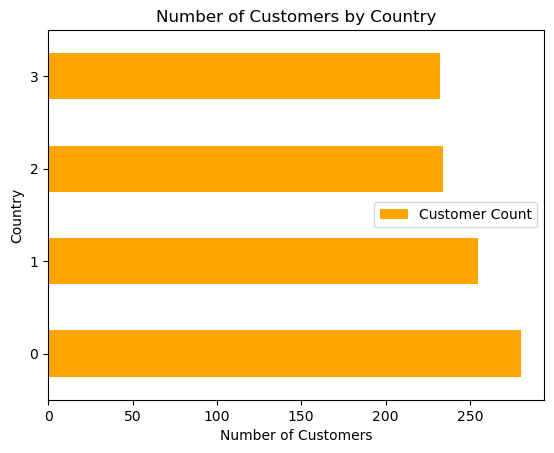

In [28]:
plt.figure(figsize=(10,6))

country_count.plot(kind='barh', color='orange')

plt.title("Number of Customers by Country")
plt.xlabel("Number of Customers")
plt.ylabel("Country")

plt.show()

In [33]:
## task 3 : Shipping Cost Optimization
data['Shipping_Days'] = (data['shipping_date'] - data['order_date']).dt.days
data[['order_date', 'shipping_date', 'Shipping_Days']].head()

,order_date,shipping_date,Shipping_Days
0,2020-05-26,2020-05-29,3
1,2022-12-29,2022-12-29,0
2,2021-03-06,2021-03-06,0
3,2020-03-11,2020-03-13,2
4,2022-03-12,2022-03-15,3


In [35]:
def shipping_category(days):
    if days <= 3:
        return "Within 3 Days"
    else:
        return "After 3 Days"

data['Shipping_Category'] = data['Shipping_Days'].apply(shipping_category)
average_shipping = data.groupby('Shipping_Category')['shipping_cost'].mean()

print(average_shipping)

Shipping_Category
After 3 Days     27.491997
Within 3 Days    27.561145
Name: shipping_cost, dtype: float64


In [36]:
## Task 4: Gender-based Analysis
male_income = customer[customer['gender'] == 'Male']['income']
female_income = customer[customer['gender'] == 'Female']['income']
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(male_income, female_income)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: -0.2447688626238352
P-Value: 0.8066856706219072


In [37]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("There is a significant difference in average income between males and females.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant difference in average income between males and females.")

Fail to Reject the Null Hypothesis
There is no significant difference in average income between males and females.


In [38]:
data['product_name'].unique()
data['product_name'].value_counts()


product_name
Sports Shoes               1763
Wireless Speaker           1717
T-Shirt                    1715
Wall Art                   1707
Activewear Set             1707
Furniture                  1695
Curtains                   1695
Jeans                      1692
Headphones                 1691
Smartphone                 1689
Jacket                     1686
Gaming Console             1686
Camera                     1685
TV                         1674
Tablet                     1673
Rugs                       1671
Kitchen Appliances         1666
Sweater                    1664
Appliance Set              1663
Smart Watch                1663
Lighting                   1652
Laptop                     1647
Bedding                    1643
Formal Shirt               1639
Home Decor                 1631
Virtual Reality Headset    1624
Skirt                      1602
Dining Set                 1594
Shoes                      1588
Dress                      1578
Name: count, dtype: int64

In [40]:
def product_category(product):
    if product in ['Sports Shoes', 'Shoes', 'T-Shirt', 'Jeans', 'Jacket',
                   'Sweater', 'Formal Shirt', 'Skirt', 'Dress', 'Activewear Set']:
        return 'Clothing'

    elif product in ['Smartphone', 'Laptop', 'Tablet', 'TV', 'Camera',
                     'Gaming Console', 'Wireless Speaker', 'Headphones',
                     'Virtual Reality Headset', 'Smart Watch']:
        return 'Electronics'

    elif product in ['Furniture', 'Curtains', 'Wall Art', 'Rugs',
                     'Lighting', 'Bedding', 'Dining Set', 'Home Decor']:
        return 'Home Decor'

    elif product in ['Kitchen Appliances', 'Appliance Set']:
        return 'Kitchen Appliances'

    else:
        return 'Others'

data['Product_Category'] = data['product_name'].apply(product_category)
contingency_table = pd.crosstab(
    data['gender'],
    data['Product_Category']
)

print(contingency_table)

Product_Category  Clothing  Electronics  Home Decor  Kitchen Appliances
gender                                                                 
Female                8133         8279        6603                1685
Male                  8501         8470        6685                1644


In [41]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 4.131069110401832
P-Value: 0.2476544245726295
Degrees of Freedom: 3


In [42]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("There is a significant association between customer gender and product category.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("There is no significant association between customer gender and product category.")

Fail to Reject the Null Hypothesis
There is no significant association between customer gender and product category.


In [44]:
## Task 5: Correlation
customer_purchase = data.groupby('customer_id')['Revenue'].sum().reset_index()

customer_purchase.columns = ['customer_id', 'Total_Purchase']

correlation_data = pd.merge(customer, customer_purchase, on='customer_id')

correlation = correlation_data['income'].corr(correlation_data['Total_Purchase'])

print("Correlation between Income and Total Purchase:", correlation)

Correlation between Income and Total Purchase: 0.02232697256112022


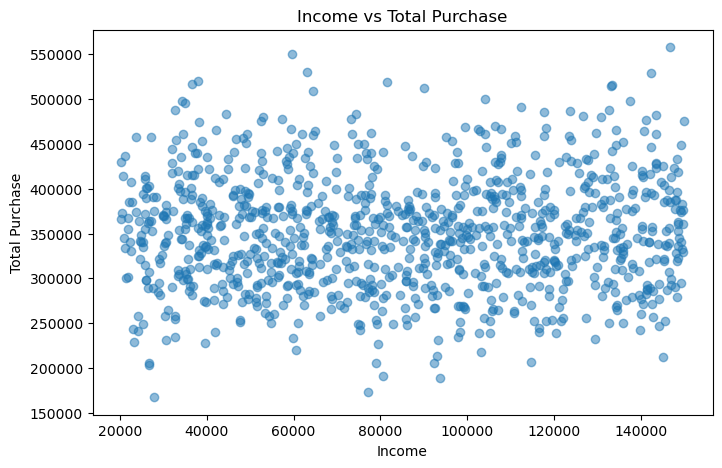

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(correlation_data['income'],
            correlation_data['Total_Purchase'],
            alpha=0.5)

plt.title("Income vs Total Purchase")
plt.xlabel("Income")
plt.ylabel("Total Purchase")

plt.show()